# RQ3: Cluster-Level Robustness for Sparse Suburban Stations

## Research Question
How does community aggregation affect sparse and suburban station performance versus station-level modeling?

## Hypothesis
H3: Community aggregation improves robustness for sparse/suburban demand slices relative to station aggregation.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.notebook_reporting import canon_graph_set, optional_csv, relative_change, require_csv

ARTIFACT_ROOT = PROJECT_ROOT / 'data' / 'artifacts' / 'experiments'
sns.set_theme(style='whitegrid', context='talk')

In [2]:
rq_results = require_csv('rq_runner/results.csv', required_columns=('rq', 'aggregation', 'graph_set', 'model', 'test_wmape'))
rq3_rows = rq_results.filter((pl.col('rq') == 'RQ3') & (pl.col('model') == 'graph_propagation')).to_pandas()
rq3_rows['graph_set'] = rq3_rows['graph_set'].apply(canon_graph_set)

cohort = require_csv('train_eval_1h/station_cohort_results.csv', required_columns=('model', 'cohort', 'test_wmape', 'n_nodes'))
cohort_rows = cohort.to_pandas()

provenance = pd.DataFrame([
    {'artifact': 'rq_runner/results.csv', 'exists': (ARTIFACT_ROOT / 'rq_runner' / 'results.csv').exists()},
    {'artifact': 'train_eval_1h/station_cohort_results.csv', 'exists': (ARTIFACT_ROOT / 'train_eval_1h' / 'station_cohort_results.csv').exists()},
    {'artifact': 'train_eval_1h/sensitivity_summary.csv', 'exists': (ARTIFACT_ROOT / 'train_eval_1h' / 'sensitivity_summary.csv').exists()},
])

inclusion = pd.DataFrame([
    {'criterion': 'RQ3 graph_propagation rows', 'value': int(len(rq3_rows))},
    {'criterion': 'Contains station aggregation', 'value': bool((rq3_rows['aggregation'] == 'station').any())},
    {'criterion': 'Contains community aggregation', 'value': bool((rq3_rows['aggregation'] == 'community').any())},
])

provenance, inclusion

(                                   artifact  exists
 0                     rq_runner/results.csv    True
 1  train_eval_1h/station_cohort_results.csv    True
 2     train_eval_1h/sensitivity_summary.csv    True,
                         criterion value
 0      RQ3 graph_propagation rows     4
 1    Contains station aggregation  True
 2  Contains community aggregation  True)

In [3]:
tradeoff = rq3_rows.pivot_table(index='graph_set', columns='aggregation', values='test_wmape', aggfunc='mean').reset_index()
if {'station', 'community'}.issubset(tradeoff.columns):
    tradeoff['community_minus_station'] = tradeoff['community'] - tradeoff['station']
    tradeoff['community_minus_station_relative'] = tradeoff.apply(lambda r: relative_change(r['community'], r['station']), axis=1)

tradeoff.sort_values('community_minus_station')

aggregation,graph_set,community,station,community_minus_station,community_minus_station_relative
1,SD+DE+DC+ATD,0.293584,0.804808,-0.511224,-0.635212
0,DE+DC,0.296140,0.801993,-0.505853,-0.630745


In [4]:
failure_cohorts = {'sparse', 'sparse_espoo', 'espoo'}
failure_slice = cohort_rows[cohort_rows['cohort'].isin(failure_cohorts)].sort_values('test_wmape', ascending=False).head(12)

robustness = optional_csv('train_eval_1h/station_robustness_statistics.csv', required_columns=('cohort', 'model', 'test_station_wmape_mean', 'test_station_wmape_ci_lower', 'test_station_wmape_ci_upper', 'paired_sign_permutation_pvalue'))
if robustness is None:
    rq3_uncertainty = pd.DataFrame()
else:
    rq3_uncertainty = robustness.filter((pl.col('model') == 'graph_propagation') & (pl.col('cohort').is_in(['sparse', 'dense', 'sparse_espoo', 'espoo']))).sort('cohort').to_pandas()

failure_slice, rq3_uncertainty

(   aggregation     graph_set              model        cohort  n_nodes  \
 12     station  SD,DE,DC,ATD      lagged_linear  sparse_espoo        6   
 26     station  SD,DE,DC,ATD        tree_lagged  sparse_espoo        6   
 5      station  SD,DE,DC,ATD  graph_propagation  sparse_espoo        6   
 11     station  SD,DE,DC,ATD      lagged_linear        sparse      113   
 25     station  SD,DE,DC,ATD        tree_lagged        sparse      113   
 19     station  SD,DE,DC,ATD     seasonal_naive  sparse_espoo        6   
 23     station  SD,DE,DC,ATD        tree_lagged         espoo      104   
 9      station  SD,DE,DC,ATD      lagged_linear         espoo      104   
 4      station  SD,DE,DC,ATD  graph_propagation        sparse      113   
 18     station  SD,DE,DC,ATD     seasonal_naive        sparse      113   
 2      station  SD,DE,DC,ATD  graph_propagation         espoo      104   
 16     station  SD,DE,DC,ATD     seasonal_naive         espoo      104   
 
     validation_wmape  

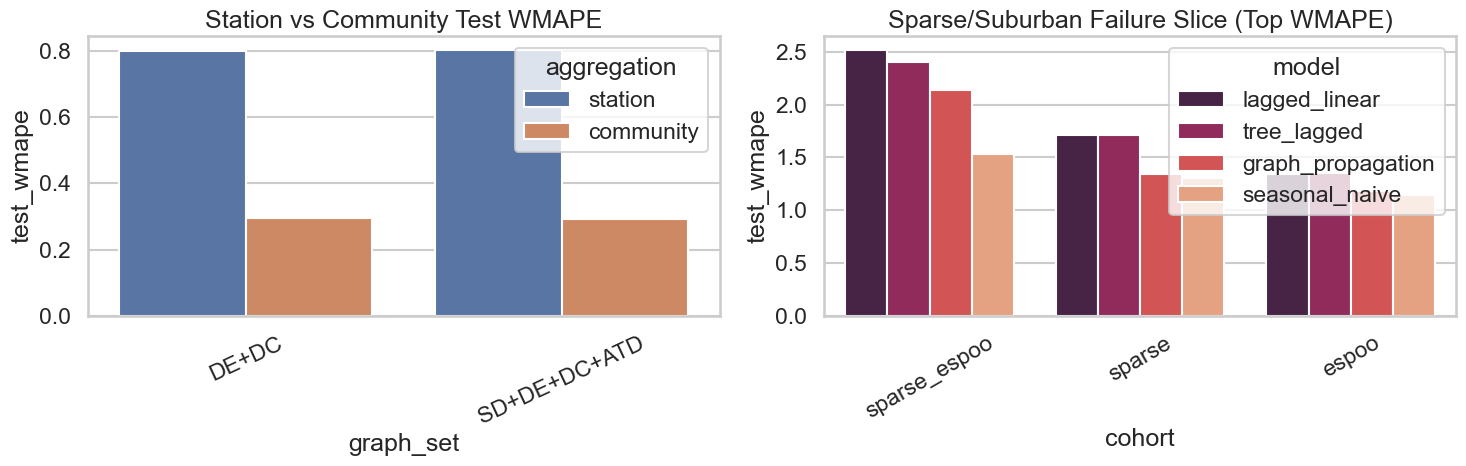

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

if {'station', 'community'}.issubset(tradeoff.columns):
    long_tradeoff = tradeoff.melt(id_vars=['graph_set'], value_vars=['station', 'community'], var_name='aggregation', value_name='test_wmape')
    sns.barplot(data=long_tradeoff, x='graph_set', y='test_wmape', hue='aggregation', ax=axes[0], palette='deep')
    axes[0].set_title('Station vs Community Test WMAPE')
    axes[0].tick_params(axis='x', rotation=25)

if not failure_slice.empty:
    sns.barplot(data=failure_slice, x='cohort', y='test_wmape', hue='model', ax=axes[1], palette='rocket')
    axes[1].set_title('Sparse/Suburban Failure Slice (Top WMAPE)')
    axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [6]:
sensitivity = optional_csv('train_eval_1h/sensitivity_summary.csv', required_columns=('sensitivity_axis', 'scope', 'model', 'delta_vs_reference'))

if sensitivity is None:
    rq3_sensitivity = pd.DataFrame()
else:
    rq3_sensitivity = sensitivity.filter(pl.col('scope').is_in(['sparse_vs_dense', 'station_vs_community'])).sort(['scope', 'model']).to_pandas()

rq3_sensitivity

,sensitivity_axis,scope,aggregation,model,setting,metric,value,reference_value,delta_vs_reference
0,threshold,sparse_vs_dense,station,graph_propagation,sparse_quantile=0.25,test_wmape,1.339834,0.764043,0.575791
1,threshold,sparse_vs_dense,station,lagged_linear,sparse_quantile=0.25,test_wmape,1.712781,0.846159,0.866622
2,threshold,sparse_vs_dense,station,seasonal_naive,sparse_quantile=0.25,test_wmape,1.305811,0.842722,0.463088
3,threshold,sparse_vs_dense,station,tree_lagged,sparse_quantile=0.25,test_wmape,1.711748,0.849917,0.861831
4,resolution,station_vs_community,station_community,graph_propagation,aggregation_resolution,test_wmape,0.804808,0.293584,0.511224
5,resolution,station_vs_community,station_community,lagged_linear,aggregation_resolution,test_wmape,0.907514,0.293983,0.613532
6,resolution,station_vs_community,station_community,seasonal_naive,aggregation_resolution,test_wmape,0.875508,0.299980,0.575528
7,resolution,station_vs_community,station_community,tree_lagged,aggregation_resolution,test_wmape,0.910934,0.290328,0.620605


## Threats To Validity (RQ3)

- Community definitions are fixed and may hide station-level heterogeneity within clusters.
- Cohort conclusions depend on sparse threshold choice and city labeling quality.
- Sparse suburban robustness can shift under different temporal splits or exogenous demand shocks.

In [7]:
if {'station', 'community'}.issubset(tradeoff.columns) and not tradeoff.empty:
    best_station = float(tradeoff['station'].min())
    best_community = float(tradeoff['community'].min())
    delta = best_community - best_station
    status = 'supported' if delta < 0 else 'mixed_or_not_supported'
    rationale = f'Best community minus best station test_wmape = {delta:.6f}'
else:
    status = 'insufficient_data'
    rationale = 'Station/community tradeoff table missing required columns.'

pd.DataFrame([{'rq': 'RQ3', 'claim_status': status, 'rationale': rationale}])

,rq,claim_status,rationale
0,RQ3,supported,Best community minus best station test_wmape =...
